<a href="https://colab.research.google.com/github/FOFM030711/SIMULACION-II/blob/main/Meteopoli_para_3D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##### <span style="color:green;">**ACTIVIDAD**</span>



**Alumna: Florencio Florencio Miriam Lizeth**

**Objetivo:** Aplicar el algoritmo **Metropolis-Hastings** para simular la función que se presenta a continucacion y poder observar graficamente los resultados obtenidos.

Gróficar la función

$$F(x)= C*exp\left(\frac{-x_1²x_2²+x_1²+x_2²-8x_1-8x_2}{2}\right)$$

Llevando a cabo con lo siguiente:

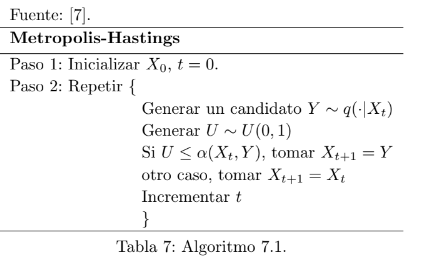

**Usaremos una propuesta normal simétrica:**

$$
Y \sim N(X_t,\sigma^2 I).
$$

Como la propuesta es simétrica,

$$
q(X_t\mid Y)=q(Y\mid X_t),
$$

por lo que la probabilidad de aceptación queda:

$$
\alpha(X_t,Y)
=
\min\left\{
1,\,
\frac{F(Y)}{F(X_t)}
\right\}.
$$

El algoritmo queda:

*  Inicializar $X_0=(x_{1,0},x_{2,0})$.
    
* Generar $Y\sim q(\cdot\mid X_t)$.
* Generar $U\sim U(0,1)$.
    
* Si $U\leq\alpha(X_t,Y)$, tomar $X_{t+1}=Y$.
    
* En otro caso, tomar $X_{t+1}=X_t$.
    
* Repetir.


In [31]:
#Bibliotecas

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


**METROPOLIS-HASTINGS**
Distribución:
$$F(x)= C*exp\left(\frac{-x_1²x_2²+x_1²+x_2²-8x_1-8x_2}{2}\right)$$

 **Considerando un dominio: $$0 <= x1 <= 1, 0 <= x2 <= 1$$**

In [11]:


# Parámetros de la simulación

N = 20000          # Número de iteraciones
burn_in = 2000     # Iteraciones iniciales que se descartan
sigma = 0.10       # Desviación de la propuesta

# Punto inicial
X0 = np.array([0.5, 0.5])

# Semilla para reproducibilidad
np.random.seed(1234)

In [12]:

# FUNCIÓN OBJETIVO


def exponente(x):
    x1, x2 = x

    return (
        -x1**2 * x2**2
        + x1**2
        + x2**2
        - 8*x1
        - 8*x2
    ) / 2



La densidad objetivo sin la constante $C$.
No necesitamos conocer $C$ porque se cancela en la razón
$$\frac{F(Y)}{F(X)}$$

In [13]:

def F(x):


    return np.exp(exponente(x))

Del **ALGORITMO METROPOLIS-HASTINGS**

In [14]:
# Matriz donde guardaremos todos los estados
X = np.zeros((N, 2))

# Inicialización
X[0] = X0

# Contador de aceptaciones
aceptados = 0



La parte fundamental del algoritmo es esta:

* Generar un candidato:

$$Y∼q(⋅∣Xt​).$$

  Usamos una distribución normal centrada en $Xt$

Como el dominio es $[0,1]^2$, **rechazamos directamente
candidatos que estén fuera del dominio**

In [15]:

# PASO 2: REPETIR


for t in range(N - 1):


    Y = X[t] + np.random.normal(0, sigma, size=2)


    if not (0 <= Y[0] <= 1 and 0 <= Y[1] <= 1):

        X[t + 1] = X[t]

        continue

Y después calculamos:
$$
\alpha(X_t,Y)=\min\left\{
1,\,
\frac{
C\exp\left[
\frac{-y_1^2y_2^2+y_1^2+y_2^2-8y_1-8y_2}{2}
\right]
}{
C\exp\left[
\frac{-x_1^2x_2^2+x_1^2+x_2^2-8x_1-8x_2}{2}
\right]
}
\right\}.
$$

Y aquí ocurre algo importante: $C$ se cancela por lo que no necesitamos calcular la constante de normalización.

Finalmente:
Procedemos a calcular la probabilidad de aceptación

$$\alpha = min\left(1,\frac{F(Y)}{F(Xt)}\right)$$


In [16]:
razon = F(Y) / F(X[t])

    alpha = min(1, razon)

 **Generar $U$ ~ $U(0,1)$**


In [17]:
 U = np.random.uniform(0, 1)

Decisión del algoritmo

In [18]:
 if U <= alpha:

        # Aceptamos el candidato
        X[t + 1] = Y
        aceptados += 1

    else:

        # Rechazamos el candidato
        X[t + 1] = X[t]


Imprimimos resultados

In [19]:

# RESULTADOS

tasa_aceptacion = aceptados / (N - 1)

print("=" * 60)
print("METROPOLIS-HASTINGS")
print("=" * 60)

print(f"Número de iteraciones: {N}")
print(f"Burn-in:               {burn_in}")
print(f"Sigma:                 {sigma}")
print(f"Punto inicial:         {X0}")
print(f"Aceptaciones:          {aceptados}")
print(f"Tasa de aceptación:    {tasa_aceptacion:.4f}")
print(f"Tasa de aceptación:    {100*tasa_aceptacion:.2f}%")

print("\nMedia de la muestra:")
print(f"E[X1] ≈ {np.mean(X[burn_in:,0]):.4f}")
print(f"E[X2] ≈ {np.mean(X[burn_in:,1]):.4f}")

print("\nDesviación estándar:")
print(f"SD[X1] ≈ {np.std(X[burn_in:,0]):.4f}")
print(f"SD[X2] ≈ {np.std(X[burn_in:,1]):.4f}")

METROPOLIS-HASTINGS
Número de iteraciones: 20000
Burn-in:               2000
Sigma:                 0.1
Punto inicial:         [0.5 0.5]
Aceptaciones:          1
Tasa de aceptación:    0.0001
Tasa de aceptación:    0.01%

Media de la muestra:
E[X1] ≈ -0.0000
E[X2] ≈ -0.0000

Desviación estándar:
SD[X1] ≈ 0.0001
SD[X2] ≈ 0.0001


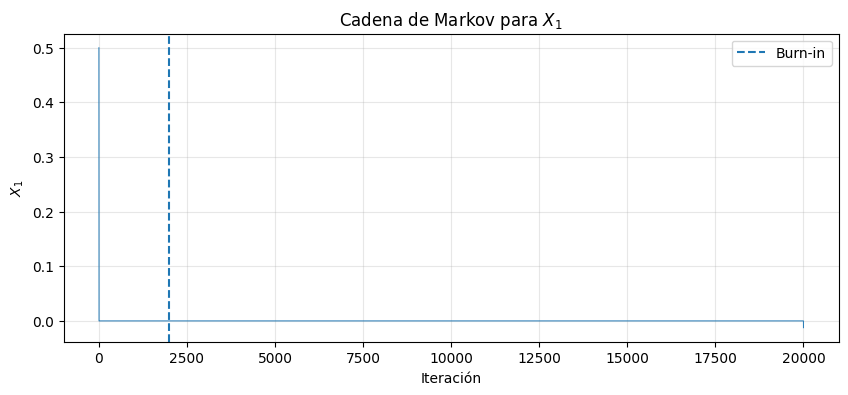

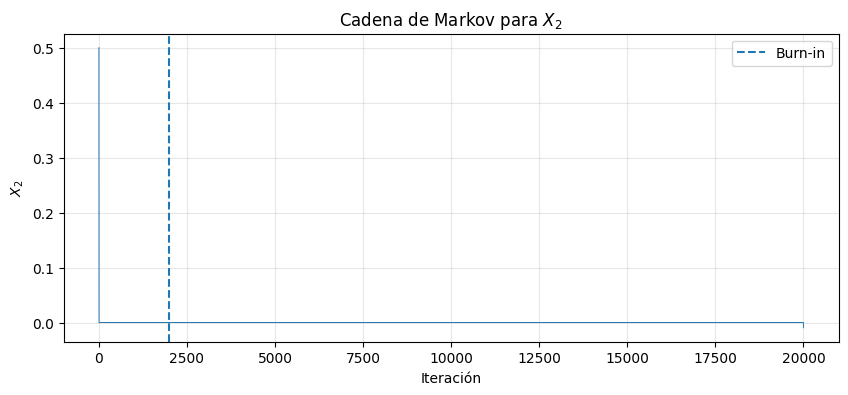

In [20]:


# GRÁFICA 1: CADENA DE X1


plt.figure(figsize=(10, 4))

plt.plot(X[:, 0], linewidth=0.7)

plt.axvline(
    burn_in,
    linestyle='--',
    label='Burn-in'
)

plt.xlabel("Iteración")
plt.ylabel("$X_1$")
plt.title("Cadena de Markov para $X_1$")
plt.legend()
plt.grid(alpha=0.3)

plt.show()



# GRÁFICA 2: CADENA DE X2

plt.figure(figsize=(10, 4))

plt.plot(X[:, 1], linewidth=0.7)

plt.axvline(
    burn_in,
    linestyle='--',
    label='Burn-in'
)

plt.xlabel("Iteración")
plt.ylabel("$X_2$")
plt.title("Cadena de Markov para $X_2$")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

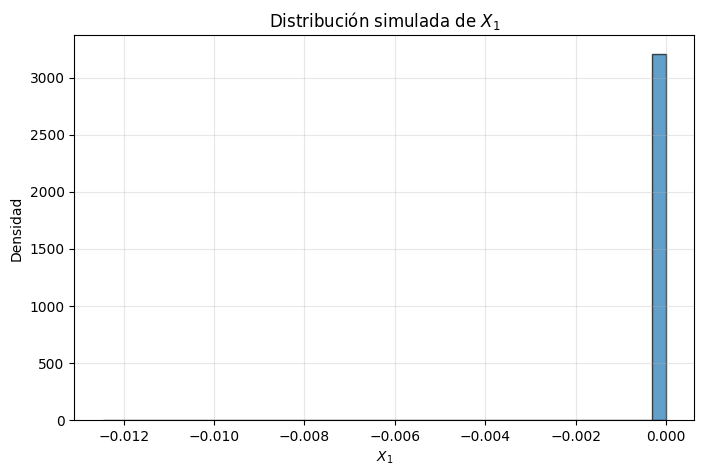

In [21]:

# GRÁFICA 3: HISTOGRAMA DE X1

muestra = X[burn_in:]

plt.figure(figsize=(8, 5))

plt.hist(
    muestra[:, 0],
    bins=40,
    density=True,
    edgecolor='black',
    alpha=0.7
)

plt.xlabel("$X_1$")
plt.ylabel("Densidad")
plt.title("Distribución simulada de $X_1$")
plt.grid(alpha=0.3)

plt.show()



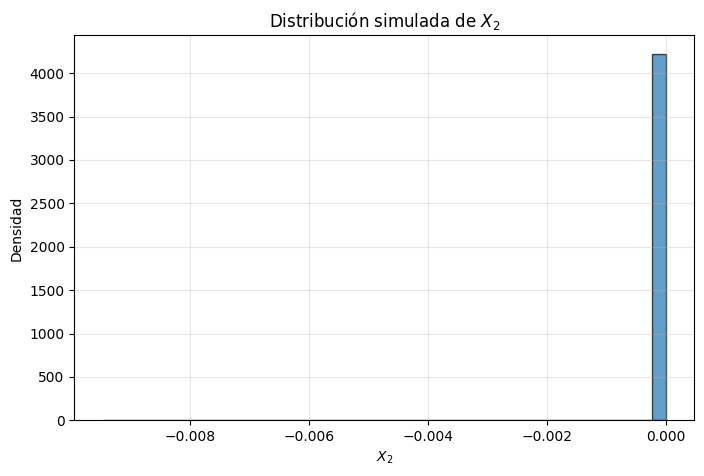

In [22]:

# GRÁFICA 4: HISTOGRAMA DE X2

plt.figure(figsize=(8, 5))

plt.hist(
    muestra[:, 1],
    bins=40,
    density=True,
    edgecolor='black',
    alpha=0.7
)

plt.xlabel("$X_2$")
plt.ylabel("Densidad")
plt.title("Distribución simulada de $X_2$")
plt.grid(alpha=0.3)

plt.show()


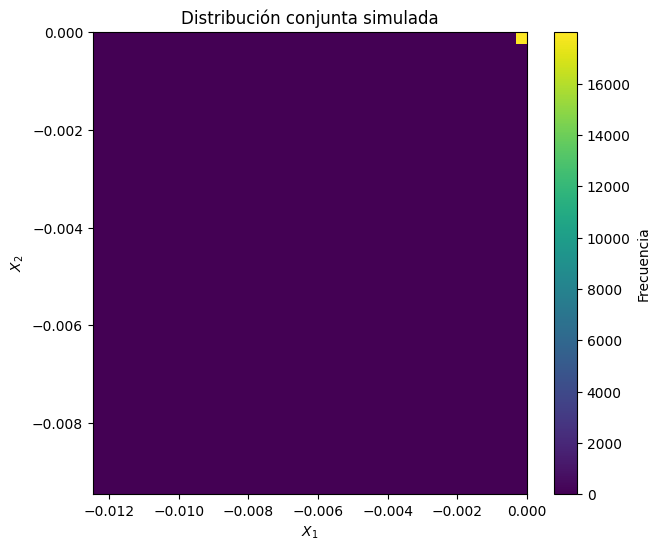

In [32]:


# GRÁFICA 5: HISTOGRAMA 2D

plt.figure(figsize=(7, 6))

plt.hist2d(
    muestra[:, 0],
    muestra[:, 1],
    bins=40
)

plt.colorbar(label="Frecuencia")

plt.xlabel("$X_1$")
plt.ylabel("$X_2$")
plt.title("Distribución conjunta simulada")

plt.show()


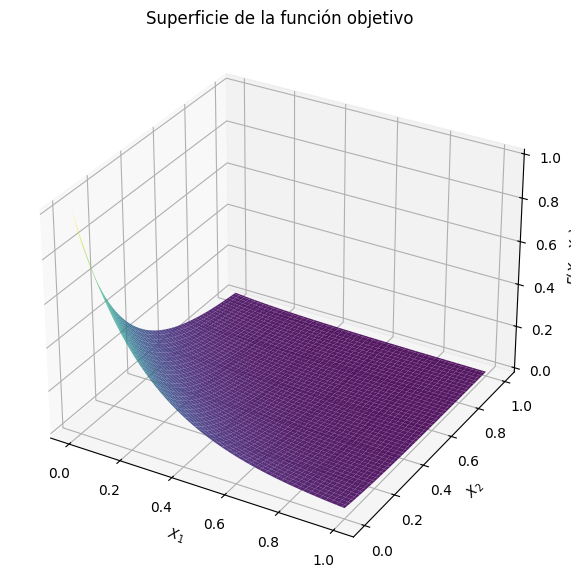

In [33]:

# GRÁFICA 6: SUPERFICIE DE LA FUNCIÓN OBJETIVO


from mpl_toolkits.mplot3d import Axes3D

x1 = np.linspace(0, 1, 100)
x2 = np.linspace(0, 1, 100)

X1, X2 = np.meshgrid(x1, x2)

Z = np.exp(
    (
        -X1**2 * X2**2
        + X1**2
        + X2**2
        - 8*X1
        - 8*X2
    ) / 2
)

fig = plt.figure(figsize=(10, 7))

ax = fig.add_subplot(111, projection='3d')

superficie = ax.plot_surface(
    X1,
    X2,
    Z,
    cmap='viridis',
    edgecolor='none',
    alpha=0.9
)

ax.set_xlabel("$X_1$")
ax.set_ylabel("$X_2$")
ax.set_zlabel("$F(X_1,X_2)$")

ax.set_title("Superficie de la función objetivo")

plt.show()

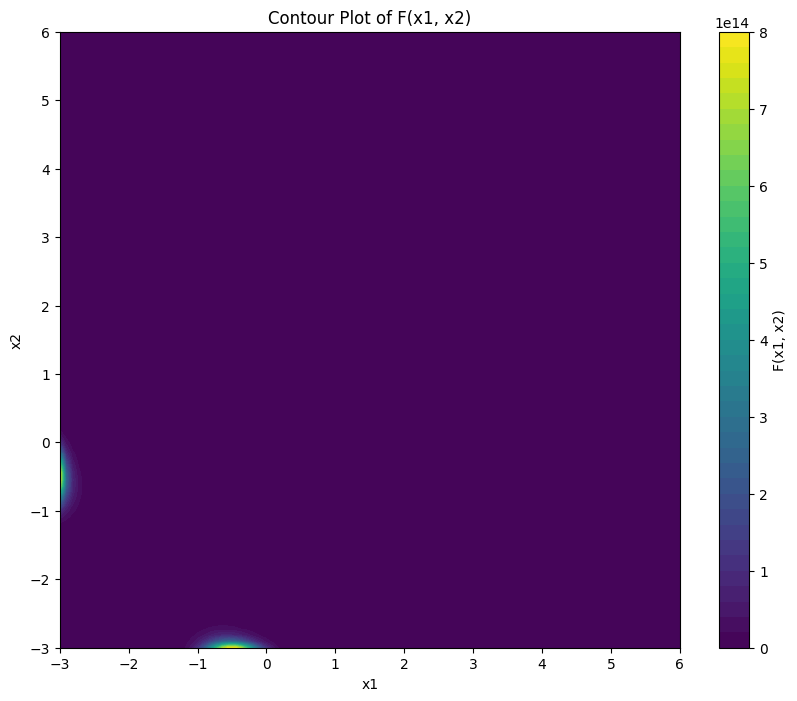

In [34]:

# Se define la contante C
C = 1

# Define the function F(x1, x2)
def F(x1, x2, C=1):
    return C * np.exp(-x1**2 * x2**2 + x1**2 + x2**2 - 8*x1 - 8*x2) / 2

# Create a meshgrid for x1 and x2 values
x1 = np.linspace(-3, 6, 100) # Adjusted range to better visualize the function's behavior
x2 = np.linspace(-3, 6, 100) # Adjusted range
X1, X2 = np.meshgrid(x1, x2)

# Calculate Z values using the function F
Z = F(X1, X2, C)

# Plotting the contour plot
plt.figure(figsize=(10, 8))
plt.contourf(X1, X2, Z, levels=50, cmap='viridis')
plt.colorbar(label='F(x1, x2)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Contour Plot of F(x1, x2)')
plt.show()

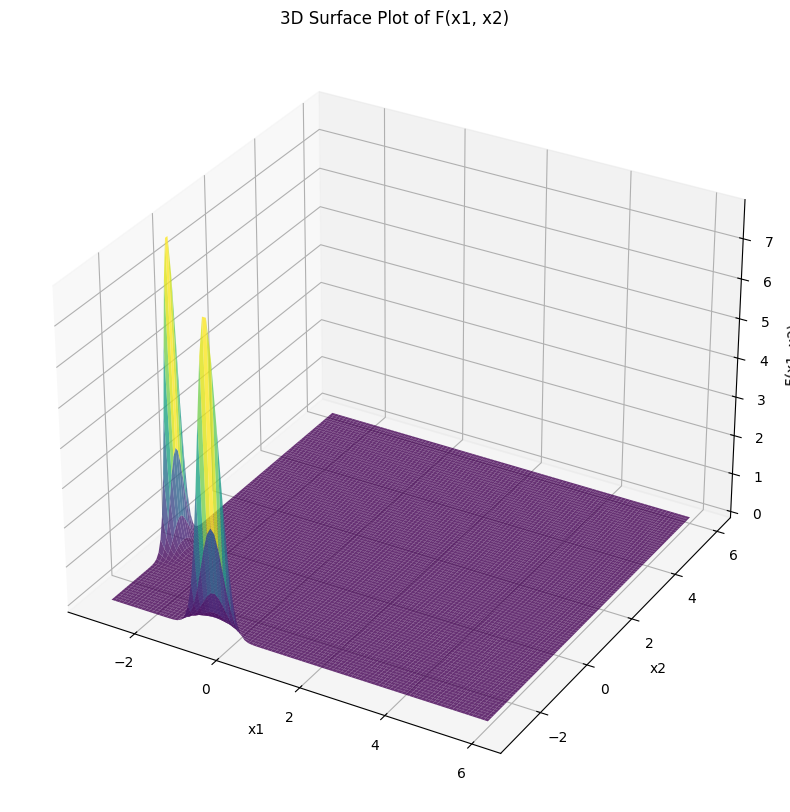

In [35]:
# Plotting the 3D surface plot
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X1, X2, Z, cmap='viridis', rstride=1, cstride=1, alpha=0.8)
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('F(x1, x2)')
ax.set_title('3D Surface Plot of F(x1, x2)')
plt.show()

**Interpretación de las gráficas:**


Las primeras dos muestran cómo evoluciona la cadena; los histogramas muestran las distribuciones marginales de $(X_1)$ y $(X_2)$; el gráfico $(X_1)$ contra $(X_2)$ muestra dónde se concentran las muestras; y la superficie muestra la forma de la función objetivo.

**Conclusión**

* La simulación se realizó con 20,000 iteraciones, un burn-in de 2,000 y $\sigma=0.1$, iniciando en $(0.5,0.5)$.

* La tasa de aceptación fue muy baja (0.01%), provocando que la cadena se moviera muy poco y que las muestras se concentraran cerca de $(0,0)$. Los histogramas y la distribución conjunta reflejan esta falta de exploración.

Por lo tanto, con los parámetros utilizados, Metropolis-Hastings no exploró adecuadamente la distribución objetivo en $[0,1]\times[0,1]$. Es necesario ajustar principalmente $\sigma$ y/o el punto inicial para mejorar la exploración.